<a href="https://colab.research.google.com/github/Malihakhan03/Machine-Learning-PBL/blob/main/Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Regression**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path="/content/drive/MyDrive/ML Dataset/housing.csv"
df=pd.read_csv(path)
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.shape


(20640, 10)

In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
#step2: Feature & Target Split
x=df.drop('median_house_value',axis=1)
y=df['median_house_value']

In [ ]:
# Re-split the preprocessed data into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print(f"New x_train shape: {x_train.shape}")
print(f"New x_test shape: {x_test.shape}")

New x_train shape: (16512, 12)
New x_test shape: (4128, 12)


In [ ]:
# Step 2.1: Handle missing values in 'total_bedrooms' by imputing with the median
x['total_bedrooms'].fillna(x['total_bedrooms'].median(), inplace=True)

# Step 2.2: One-hot encode the 'ocean_proximity' categorical column
x = pd.get_dummies(x, columns=['ocean_proximity'], drop_first=True)

/tmp/ipykernel_708/1021827595.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x['total_bedrooms'].fillna(x['total_bedrooms'].median(), inplace=True)


In [ ]:
x.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,False,False,True,False


In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   ocean_proximity_INLAND      20640 non-null  bool   
 9   ocean_proximity_ISLAND      20640 non-null  bool   
 10  ocean_proximity_NEAR BAY    20640 non-null  bool   
 11  ocean_proximity_NEAR OCEAN  20640 non-null  bool   
dtypes: bool(4), float64(8)
memory usage: 1.3 MB


In [ ]:
#step 4: Train Linear Regression Model
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
#step 5: Prediction
y_pred=model.predict(x_test)

In [ ]:
#step 6:Model Evaluation
import numpy as np
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

In [ ]:
print("\n Model Evaluation Matrices:")
print("Mean Absolute Error (mae):{mae}")
print("Mean Squared Error (mse):{mse}")
print("Root Mean Squared Error (rmse):{rmse}")
print("R squared Score(R2):{r2}")


 Model Evaluation Matrices:
Mean Absolute Error (mae):{mae}
Mean Squared Error (mse):{mse}
Root Mean Squared Error (rmse):{rmse}
R squared Score(R2):{r2}


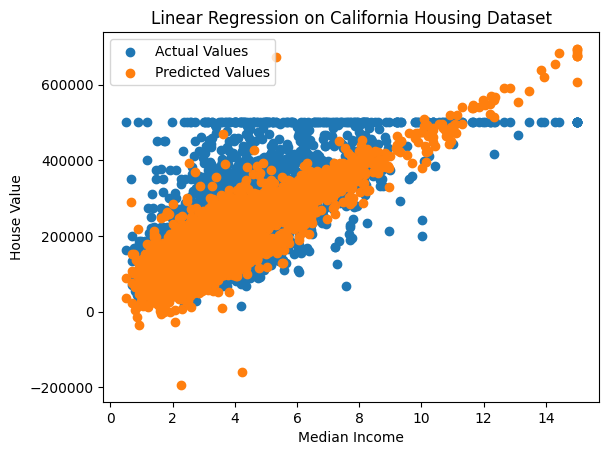

In [ ]:
plt.scatter(x_test['median_income'], y_test, label='Actual Values')
plt.scatter(x_test['median_income'], y_pred, label='Predicted Values')
plt.xlabel('Median Income')
plt.ylabel('House Value')
plt.title('Linear Regression on California Housing Dataset')
plt.legend()
plt.show()

# **Multiple Linear Regression**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/ML Dataset/housing.csv"
df=pd.read_csv(path)
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.shape

(20640, 10)

In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
#step2: Feature & Target Split
x=df.drop('median_house_value',axis=1)
y=df['median_house_value']

In [ ]:
x.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY


In [ ]:
y.head()

,median_house_value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(16512, 9)

In [ ]:
x_test.shape

(4128, 9)

In [ ]:
y_train.shape

(16512,)

In [ ]:
y_test.shape

(4128,)

In [ ]:
# Step 2.1: Handle missing values in 'total_bedrooms' by imputing with the median
x['total_bedrooms'].fillna(x['total_bedrooms'].median(), inplace=True)

# Step 2.2: One-hot encode the 'ocean_proximity' categorical column
x = pd.get_dummies(x, columns=['ocean_proximity'], drop_first=True)

/tmp/ipykernel_708/1021827595.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x['total_bedrooms'].fillna(x['total_bedrooms'].median(), inplace=True)


In [ ]:
x.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,False,False,True,False


In [ ]:
# Re-split the preprocessed data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"New x_train shape: {x_train.shape}")
print(f"New x_test shape: {x_test.shape}")

New x_train shape: (16512, 12)
New x_test shape: (4128, 12)


In [ ]:
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model instance
model = LinearRegression()

# Train the model using the training data
model.fit(x_train, y_train)

print("Model training complete.")
print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")

Model training complete.
Model coefficients: [-2.68382734e+04 -2.54683520e+04  1.10218508e+03 -6.02150567e+00
  1.02789395e+02 -3.81729064e+01  4.82527528e+01  3.94739752e+04
 -3.97866562e+04  1.36125073e+05 -5.13664222e+03  3.43114007e+03]
Model intercept: -2275547.3817163985


Mean Absolute Error (MAE): 50670.74
Mean Squared Error (MSE): 4908476721.16
Root Mean Squared Error (RMSE): 70060.52
R-squared (R2): 0.63


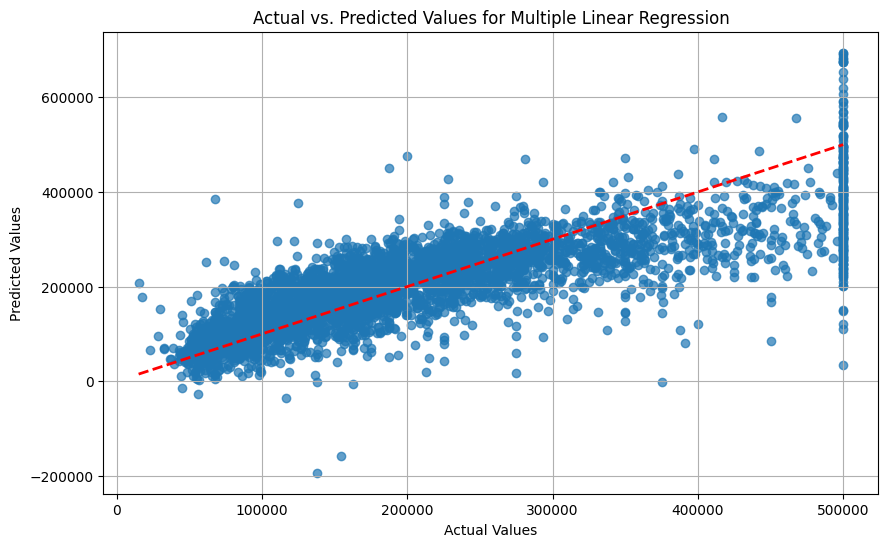

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = model.predict(x_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line representing perfect predictions
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values for Multiple Linear Regression')
plt.grid(True)
plt.show()

# **Polynomial Regression**

## Polynomial Regression Implementation

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Step 1: Create Polynomial Features
degree = 2  # You can change the degree of the polynomial
poly_features = PolynomialFeatures(degree=degree, include_bias=False)

x_train_poly = poly_features.fit_transform(x_train)
x_test_poly = poly_features.transform(x_test)

print(f"Original x_train shape: {x_train.shape}")
print(f"Transformed x_train_poly shape: {x_train_poly.shape}")

Original x_train shape: (16512, 12)
Transformed x_train_poly shape: (16512, 90)


In [ ]:
from sklearn.linear_model import LinearRegression

# Step 2: Train a Linear Regression model on the polynomial features
poly_model = LinearRegression()
poly_model.fit(x_train_poly, y_train)

print("Polynomial Regression Model training complete.")
print(f"Model coefficients: {poly_model.coef_}")
print(f"Model intercept: {poly_model.intercept_}")

Polynomial Regression Model training complete.
Model coefficients: [-1.86369523e+05  2.87272828e+05 -7.19886776e+04  1.54021396e+03
 -5.29950189e+03  7.03155197e+01 -3.22744873e+03 -1.03713297e+06
 -3.09075522e+04 -4.25656829e+00 -1.26570311e+07 -5.33815480e+05
 -5.31862077e+02  2.87556750e+03 -9.01358260e+02  1.92027692e+01
 -7.45019514e+01  2.40281280e+00 -3.51667521e+01 -1.32279760e+04
  7.29112528e+02  4.31278299e+02 -2.48206181e+05 -1.03202910e+04
  1.48029957e+03 -1.05171843e+03  1.98863336e+01 -9.25602155e+01
  5.76786060e+00 -2.99077658e+01 -1.38296672e+04  1.70475283e+03
 -1.21761840e+02 -1.32134558e+05 -4.88018678e+03  2.03041439e+01
 -2.31267168e-01  2.69987160e+00 -1.45316622e+00  3.53680245e+00
  1.60273541e+02  7.73428759e+02 -3.70601545e+02 -4.90146961e+02
  1.60735454e+02 -2.21174234e-03  2.58677516e-02 -5.95239410e-03
  1.90368462e-02  9.73730849e+00 -1.52612991e+01 -4.65840385e+02
  1.44366418e+01  5.42211443e+00 -1.13604874e-01  3.07423146e-02
 -5.99999996e-02 -3.337

Polynomial Regression - Mean Absolute Error (MAE): 46380.08
Polynomial Regression - Mean Squared Error (MSE): 4505252849.39
Polynomial Regression - Root Mean Squared Error (RMSE): 67121.18
Polynomial Regression - R-squared (R2): 0.66


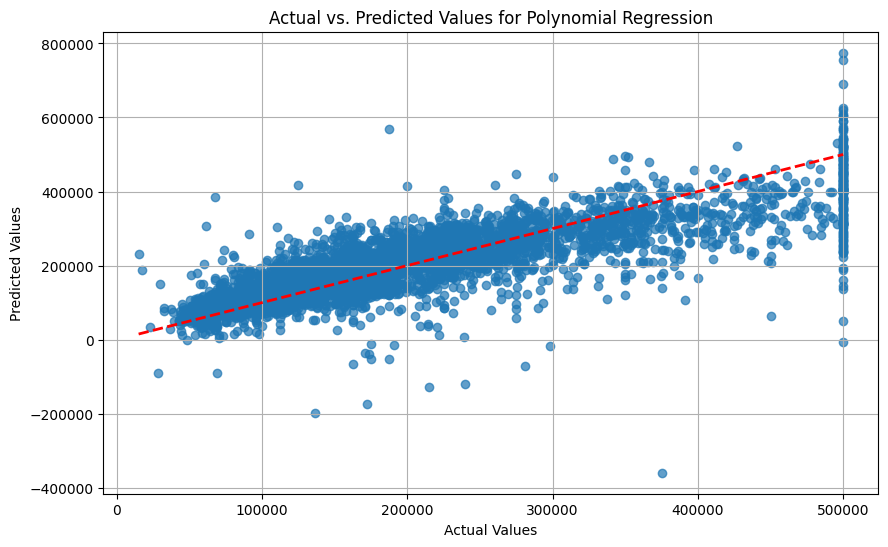

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Step 3: Make predictions on the transformed test set
y_pred_poly = poly_model.predict(x_test_poly)

# Step 4: Evaluate the Polynomial Regression Model
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial Regression - Mean Absolute Error (MAE): {mae_poly:.2f}")
print(f"Polynomial Regression - Mean Squared Error (MSE): {mse_poly:.2f}")
print(f"Polynomial Regression - Root Mean Squared Error (RMSE): {rmse_poly:.2f}")
print(f"Polynomial Regression - R-squared (R2): {r2_poly:.2f}")

# Visualize predictions vs actual values for Polynomial Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_poly, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line representing perfect predictions
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values for Polynomial Regression')
plt.grid(True)
plt.show()